# TS4:"Primeras nociones de estimacion espectral"

## Alumno: Suarez Lucila

En esta experiencia quisimos ver que sucedia cuando a una señal seno+ruido le aplicábamos ,en el dominio del tiempo, 4 ventanas distintas: rectangular, flattop, blackmanharris y la triangular; para evaluar, a partir de su espectro en frecuencia, cual de ellas da mejor estimación de amplitud y frecuencia

Comenzamos generando la siguiente señal: $$x(n) = a_0sen(\Omega_1 n) + n_a(n)$$
Siendo: $$a_0 = \sqrt{2}$$ 
$$\Omega_1 = \Omega_0 + f_r (2\pi/N)$$
$$\Omega_0 = \pi/2$$
Y la variable aleatoria definida por las siguiente distribucion de probabilidad $$f_r \sim \mathcal{U}(-2,2)$$ 
$$n_a \sim \mathcal{N}(0, \sigma^2)$$ 


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as ssw


#%% PARÁMETROS GENERALES
Ps = 1 # potencia de la senoidal (normalizada a 1W)
A= np.sqrt(2*Ps) #amplitud del seno
Vmed = 0
phi = 0
N = 1000
R = 200
fs = 1000
SNR = [3, 10] 
deltaf = 2*np.pi/N

Luego modelamos n como un vector columna de (1000,1) y fr como un vector fila de (1,200), y al multiplicarlos nos queda una matriz de (1000, 200). Cada una de las 1000 filas representa una muestra temporal n y cada una de las 200 columnas representa un experimento con un fr distinto.

In [12]:
#%% CREO LOS VECTORES
n = np.arange(N)
fr = np.random.uniform(-2,2,R) # la distribución que me dan

columna_n = n.reshape((N,1))
fila_fr = fr.reshape((1,R))

# matriz_fr = columna_n * fila_fr --> todavia no armo la matriz


#%% GENERO EL SENO Y EL RUIDO --> x(n):seno + ruido
# para el seno:
omega0 = np.pi/2
omega1 = omega0 + (fila_fr * deltaf) 

# ARMO LA MATRIZ:
matriz_fase = columna_n * omega1

x_seno = A*np.sin(matriz_fase)

ventanas = {
    'Rectangular': ssw.get_window('rectangular', N),
    'Flat-top': ssw.get_window('flattop', N),
    'Blackman-Harris': ssw.get_window('blackmanharris', N),
    'Triangular': ssw.get_window('triang', N)
}

omega_eje = 2 * np.pi * np.fft.fftfreq(N)
idx_omega0 = N // 4

A continuacion, se explica brevemente que es un ventaneo para que el análisis del grafico sea mas preciso. Matemáticamente, multiplicar a una señal finita por una ventana en el dominio del tiempo equivale a realizar una convolución de sus transformadas de Fourier (DTFT) en la frecuencia; que en nuestro trabajo es lo que estaría haciendo el estimador de amplitud $a$. Ya que, $$\hat{a}_1 = /X_w^i(\Omega_0)/ = /\mathcal{F}\{x(n) \cdot w_i(n)\}|$$
Lo que sucede, es que los lobulos principales de las ventanas ensanchan los picos espectrales de las señales, limitando la resolucion para distinguir tonos muy cercanos entre si. Y los lobulos secundarios distribuyen la energia hacia otras frecuencias, creando un "piso de ruido" que puede ocultar componentes de baja amplitud.


Estimación de Amplitud:
Ventana            | s_a (Sesgo)  | v_a (Varianza)
------------------------------------------------
Rectangular        |    -0.899871 |     0.202108
Flat-top           |    -0.110235 |     0.022714
Blackman-Harris    |    -0.477456 |     0.126448
Triangular         |    -0.766200 |     0.238431

Estimación de Frecuencia:
Ventana            | s_w (Sesgo)  | v_w (Varianza)
------------------------------------------------
Rectangular        |     0.000021 |     0.000004
Flat-top           |     0.000084 |     0.000008
Blackman-Harris    |    -0.000011 |     0.000004
Triangular         |    -0.000011 |     0.000004

Estimación de Amplitud:
Ventana            | s_a (Sesgo)  | v_a (Varianza)
------------------------------------------------
Rectangular        |    -0.900330 |     0.204144
Flat-top           |    -0.111522 |     0.017484
Blackman-Harris    |    -0.479152 |     0.124403
Triangular         |    -0.772647 |     0.244093

Estimación de Frecuencia:
Ventana 

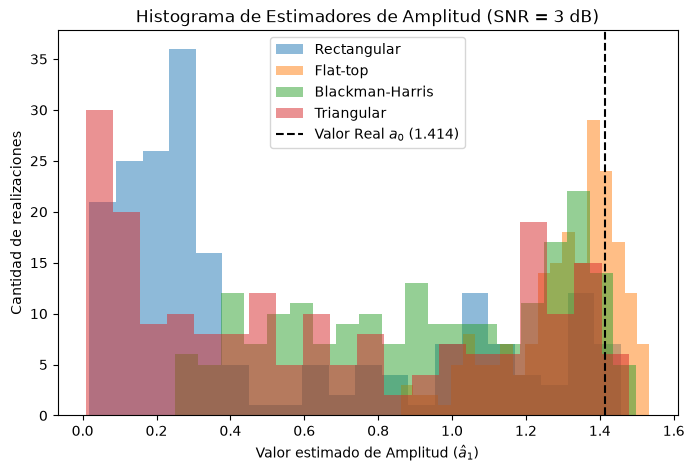

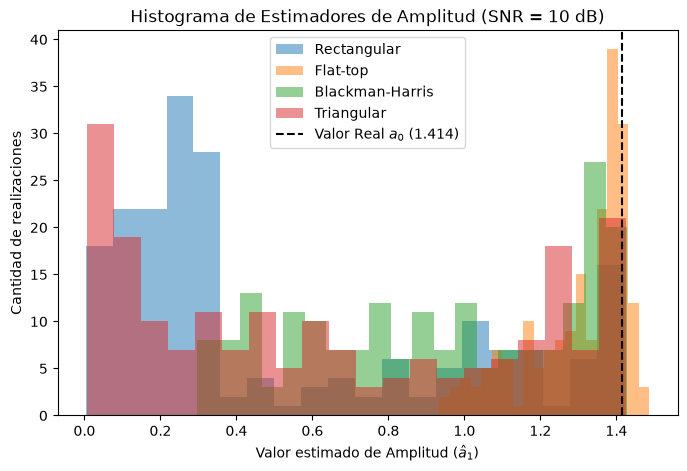

In [13]:
for snr in SNR:
    Pruido = 10 ** (-snr / 10)
    sigma=np.sqrt(Pruido)
    na_r=np.random.normal(0,sigma,(N,R))
    
    xn=x_seno+na_r
    sesgo_amp, var_amp = {}, {}
    sesgo_freq, var_freq = {}, {}
    
    plt.figure(figsize=(8,5))
    
    for nombre_win, win in ventanas.items():
        xn_win = xn*win[:, None]
        X_w = np.fft.fft(xn_win, axis=0)
        espectro_amp=2*np.abs(X_w)/np.sum(win)
        
        a_hat = espectro_amp[idx_omega0, :]
        
        idx_max=np.argmax(espectro_amp[:N//2, :], axis=0)
        omega1_hat=omega_eje[idx_max]
        plt.hist(a_hat, bins=20, alpha=0.5, label=nombre_win)

        sesgo_amp[nombre_win]=np.mean(a_hat) - A
        var_amp[nombre_win]=np.var(a_hat, ddof=0)
        
        sesgo_freq[nombre_win]=np.mean(omega1_hat - omega1)
        var_freq[nombre_win]=np.var(omega1_hat - omega1, ddof=0)
    plt.axvline(A, color='black', linestyle='--', label=f'Valor Real $a_0$ ({A:.3f})')
    plt.title(f'Histograma de Estimadores de Amplitud (SNR = {snr} dB)')
    plt.xlabel('Valor estimado de Amplitud ($\hat{a}_1$)')
    plt.ylabel('Cantidad de realizaciones')
    plt.legend()
    
    print("\nEstimación de Amplitud:")
    print(f"{'Ventana':<18} | {'s_a (Sesgo)':<12} | {'v_a (Varianza)':<12}")
    print("-" * 48)
    for win_name in ventanas.keys():
        print(f"{win_name:<18} | {sesgo_amp[win_name]:12.6f} | {var_amp[win_name]:12.6f}")
        
    print("\nEstimación de Frecuencia:")
    print(f"{'Ventana':<18} | {'s_w (Sesgo)':<12} | {'v_w (Varianza)':<12}")
    print("-" * 48)
    for win_name in ventanas.keys():
        print(f"{win_name:<18} | {sesgo_freq[win_name]:12.6f} | {var_freq[win_name]:12.6f}")

plt.show()

Como se menciono anteriormente, en este trabajo analizamos 4 ventanas: Rectangular, Flat-top, Blackman-Harris y Triangular. La ventana rectangular posee el lóbulo principal mas angosto, lo que le otorga la mayor resolución en frecuencia. Sin embargo, tiene lobulos secundarios muy altos, lo que genera una fuga espectral y un alto sesgo si la frecuencia no cae justo dentro de un bin de la DFT. 
La flat-top es la que tiene el menor sesgo en amplitud, podemos decir que es insesgada, su lóbulo principal es muy ancho, lo que elimina el error por desparramo de frecuencia. 
La blackman-harris sus lobulos secundarios son extremadamente bajos, lo que hace que no tenga tanta fuga espectral. Y por ultimo, tenemos la triangular (que fue la elegida por nosotros) su lóbulo principal es el doble de ancho que la de rectangular y sus lobulos secundarios caen mas rápido, reduciendo la fuga espectral pero perdiendo resolución en frecuencia.

Dicho esto, se observa como en los dos graficos la Flato-top es la que mas se acerca al valor esperado. Vale aclarar que en el grafico con SNR=10dB se nota una mayor precision, esto es debido a que, al aumentar la SNR, aumenta la informacion, y se disminuye la varianza de los estimadores; haciendo que se converga al verdadero valor. 